In [ ]:
import osmnx as ox
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString
from tqdm import tqdm
from scipy.spatial import ConvexHull

ox.settings.use_cache = True

In [ ]:
def get_city_blocks(place_name):
    G = ox.graph_from_place(place_name, network_type="drive")
    G = ox.project_graph(G)
    gdf_nodes, gdf_edges = ox.graph_to_gdfs(G, nodes=True, edges=True)

    # recursively removing all nodes and edges that have less than 2 connections
    while True:
        to_remove = []
        for node in G.nodes:
            successors = list(G.successors(node))
            predecessors = list(G.predecessors(node))
            if len(predecessors) + len(successors) < 2:
                to_remove.append(node)
        if len(to_remove) == 0:
            break
        G.remove_nodes_from(to_remove)

    # plotting and saving the city network
    fig, ax = ox.plot_graph(
        G,
        show=False,
        close=False,
        node_size=0,
        edge_linewidth=2,
        edge_color="black",
        bgcolor="white",
        figsize=(8, 8),
    )
    ncname = place_name.split(",")[0].replace(" ", "_")
    # plt.savefig(f"1louf_LVN_{ncname}_network.png")
    plt.show()

    blocks = []
    for cycle in tqdm(nx.cycle_basis(nx.Graph(G))):
        coords = [
            gdf_nodes.loc[node].geometry for node in cycle if node in gdf_nodes.index
        ]
        if len(coords) >= 3:
            poly = Polygon(coords)
            ogpoly = poly
            ogarea = poly.area
            # adding edges to the polygon to calculate correct area
            try:
                for i in range(len(coords) - 1):
                    poly = poly.union(LineString([coords[i], coords[i + 1]]))
            except Exception as e:
                # print(e)
                continue
            narea = poly.area
            # print(
            #     f"Original Area: {ogarea}, New Area: {narea}, Area Difference: {narea - ogarea}"
            # )
            if poly.is_valid:
                blocks.append((ogpoly, narea))
    # plotting blocks
    fig, ax = plt.subplots(figsize=(8, 8))
    for block, area in blocks:
        x, y = block.exterior.xy
        ax.fill(x, y, alpha=0.5)
    ax.set_aspect("equal", "datalim")
    plt.title(f"Blocks of {place_name}")
    # plt.savefig(f"louf_LVN_{ncname}_blocks.png")
    plt.show()

    return blocks

In [209]:
def minimum_bounding_circle_area(polygon):
    points = np.array(polygon.exterior.coords)
    hull = ConvexHull(points)
    hull_points = points[hull.vertices]

    def enclosing_circle(points):
        from scipy.spatial import distance_matrix

        dist_mat = distance_matrix(points, points)
        i, j = np.unravel_index(dist_mat.argmax(), dist_mat.shape)
        center = (points[i] + points[j]) / 2
        radius = np.linalg.norm(points[i] - center)
        return center, radius

    center, radius = enclosing_circle(hull_points)
    return np.pi * radius**2


def compute_shape_factor(blocks):
    block_data = []
    for block, area in tqdm(blocks):
        if not isinstance(block, Polygon):
            continue
        # circumscribed_circle_area = (
        # np.pi * (block.length / (2 * np.pi)) ** 2
        # )  # Approximate, a bit faster
        circumscribed_circle_area = minimum_bounding_circle_area(block)

        phi = area / circumscribed_circle_area if circumscribed_circle_area > 0 else 0
        block_data.append((area, phi))

    return np.array(block_data)


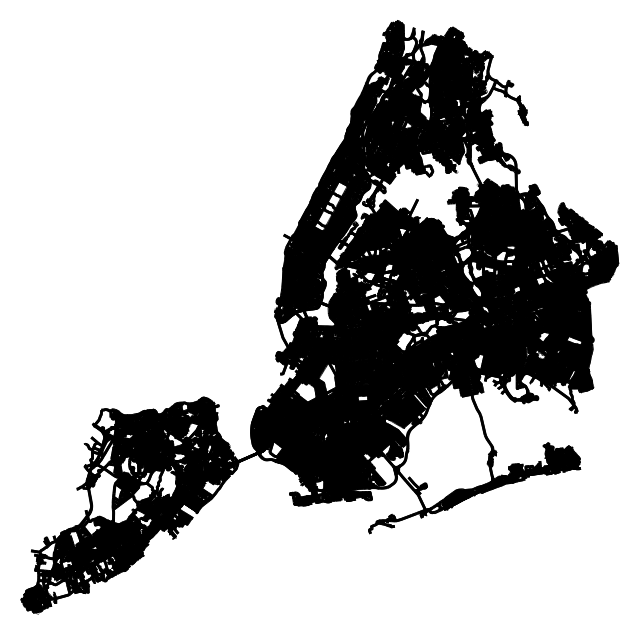

100%|██████████| 36220/36220 [21:00<00:00, 28.72it/s]  


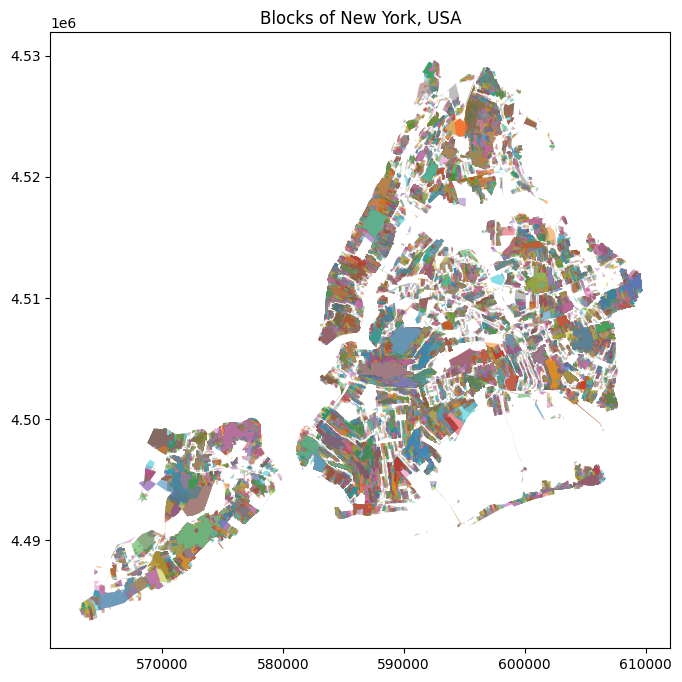

100%|██████████| 30985/30985 [00:26<00:00, 1187.10it/s]


In [210]:
# city_name ="Lviv, Ukraine"
# city_name = "Manhattan, New York, USA"
# city_name = "Brooklyn, New York, USA"
# city_name = "Bronx, New York, USA"
# city_name = "Queens, New York, USA"
# city_name = "Staten Island, New York, USA"

city_name = "New York, USA"

blocks = get_city_blocks(city_name)
block_data = compute_shape_factor(blocks)

In [254]:
# bin_ranges = [
#     (0, 1e3),
#     (1e3, 1e4),
#     (1e4, 1e5),
#     (1e5, np.inf),
# ]

bin_ranges = [
    (0, 1e3),
    (1e3, 1e4),
    (1e4, 1e5),
    (1e5, 1e6),
    (1e6, 1e7),
    (1e7, 0),
]

# bin_ranges = [
#     (1e3/2, 1e4/2),
#     (1e4/2, 1e5/2),
#     (1e5/2, 1e6/2),
#     (1e6/2, 1e7/2),
#     (1e7/2, np.inf),
# ]

# color_names = ["green", "orange", "blue", "red"]
# color_names = ["#66C2A5", "#FC8D62", "#8DA0CB", "#E78AC3"]
color_names = ["brown", "#66C2A5", "#FC8D62", "#8DA0CB", "#E78AC3", "white"]

def plot_fingerprint(block_data, city_name):

    if len(block_data) == 0:
        print(f"No valid blocks found for {city_name}")
        return

    bin_indices = np.zeros(len(block_data), dtype=int)
    for i, (a_min, a_max) in enumerate(bin_ranges):
        bin_indices[(block_data[:, 0] >= a_min) & (block_data[:, 0] < a_max)] = i + 1

    plt.figure(figsize=(8, 6))

    colors = [
        color_names[i-1] if i >= 0 else "#000"
        for i in bin_indices
    ]

    alphas = [
        0.7 if i != "white" else 0
        for i in colors
    ]

    plt.scatter(
        block_data[:, 1],
        block_data[:, 0],
        c=colors,
        alpha=alphas,
        edgecolors="k",
        s=block_data[:, 0] / 1000
    )

    plt.xlim(0, 1)
    plt.yscale("log")
    plt.ylim(1e1, 1e8)
    plt.xlabel("Shape Factor (Φ)")
    plt.ylabel("Block Area (log scale)")
    ncname = city_name.split(",")[0].replace(" ", "_")
    plt.title(f"Fingerprint of {ncname}")
    # plt.savefig(f"louf_LVN_{ncname}_ca_t.png")
    plt.show()


def plot_pd(block_data, city_name):
    if len(block_data) == 0:
        print(f"No valid blocks found for {city_name}")
        return

    fig, ax = plt.subplots(figsize=(8, 5))

    # area_labels = ["< 10^3", "10^3 - 10^4", "10^4 - 10^5", "> 10^5"]
    colors = color_names

    # bin_edges = np.linspace(0, 1, 51)  # 50 bins between 0 and 1
    bin_edges = np.linspace(0, 1, 30)  # seems to be different in different plots
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    total_blocks = len(block_data)

    total_hist = np.zeros_like(bin_centers)

    for i, (a_min, a_max) in enumerate(bin_ranges):
        phi_values = block_data[
            (block_data[:, 0] >= a_min) & (block_data[:, 0] < a_max), 1
        ]
        n = len(phi_values)
        if n == 0:
            continue
        hist, _ = np.histogram(phi_values, bins=bin_edges, density=True)
        weighted_hist = hist * (n / total_blocks)
        total_hist += weighted_hist
        hist, _ = np.histogram(phi_values, bins=bin_edges, density=True)
        weighted_hist = hist * (n / total_blocks)
        ax.plot(bin_centers, weighted_hist, color=colors[i])#, label=area_labels[i])

    ax.plot(
        bin_centers,
        total_hist,
        color="gray",
        linewidth=0.5,
        linestyle="--",
    )
    ax.fill_between(bin_centers, total_hist, color="gray", alpha=0.1)


    ax.set_xlabel(r"$\Phi$", fontsize=14)
    ax.set_ylabel(r"$f(\Phi)$", fontsize=14)
    ax.set_title(f"{city_name}", fontsize=18, weight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


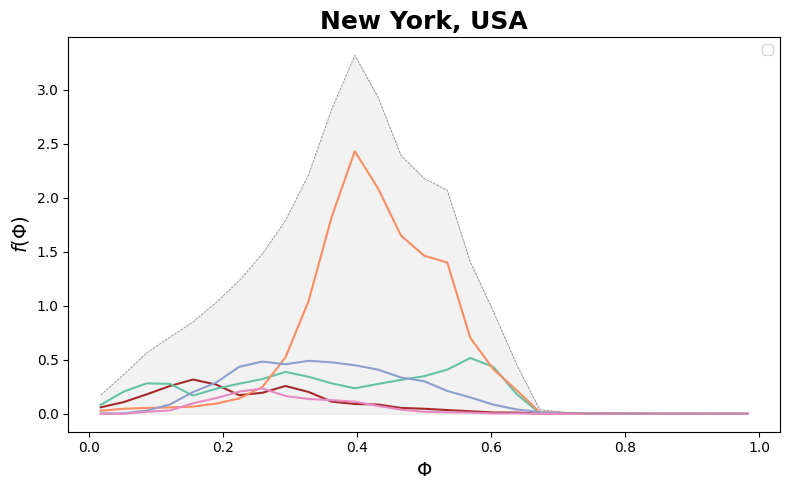

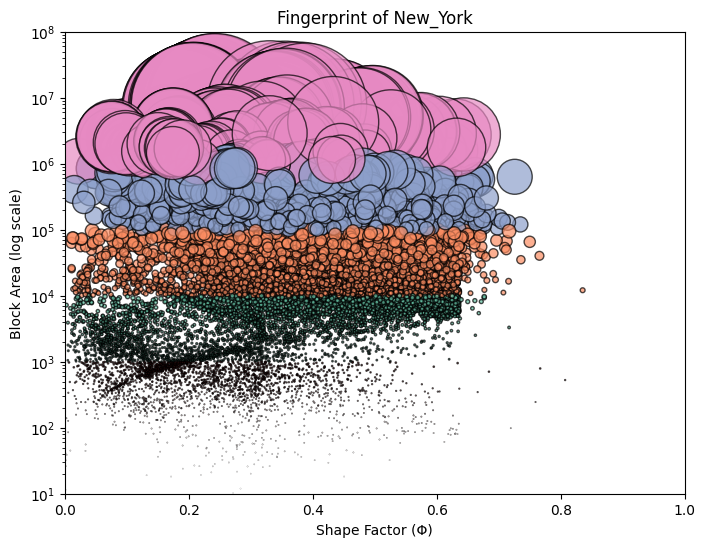

In [212]:
plot_pd(block_data)
plot_fingerprint(block_data)

1. Split blocks into area bins:
   $$ \alpha_1 = [10^3, 10^4) $$
   $$ \alpha_2 = [10^4, 10^5) $$

2. Compute:
   $$ f_\alpha^{(a)}(\Phi) = \text{normalized histogram of } \Phi \text{ in bin } \alpha \text{ for city } a $$

3. Distance between two cities in bin $\alpha$:
   $$ d_\alpha(a, b) = \int_0^1 \left| f_\alpha^{(a)}(\Phi) - f_\alpha^{(b)}(\Phi) \right|^n \, d\Phi $$
   
   n may be 1 or 2.

4. Total distance:
   $$ D(a, b) = \sum_\alpha d_\alpha(a, b)^2 $$

In [213]:
def compute_f_alpha(block_data, bin_edges=np.linspace(0, 1, 51)):
    area_bins = [
        (1e3, 1e4),
        (1e4, 1e5),
    ]

    f_alpha = {}
    for i, (a_min, a_max) in enumerate(area_bins):
        phi_values = block_data[(block_data[:, 0] >= a_min) & (block_data[:, 0] < a_max), 1]
        if len(phi_values) == 0:
            f_alpha[i] = np.zeros(len(bin_edges) - 1)
        else:
            hist, _ = np.histogram(phi_values, bins=bin_edges, density=True)
            f_alpha[i] = hist  # Already normalized to unit area
    return f_alpha


In [ ]:
def distance_between_cities(city_a_data, city_b_data, n=1):
    bin_edges = np.linspace(0, 1, 51)

    f_a = compute_f_alpha(city_a_data, bin_edges)
    f_b = compute_f_alpha(city_b_data, bin_edges)

    D = 0
    for alpha in f_a:
        diff = np.abs(f_a[alpha] - f_b[alpha]) ** n
        d_alpha = np.sum(diff * (bin_edges[1] - bin_edges[0]))  # integral approximation
        D += d_alpha ** 2

    return D


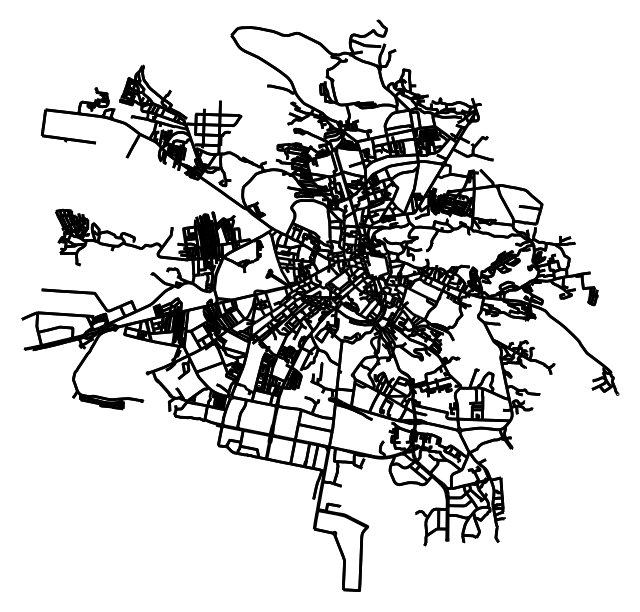

100%|██████████| 1298/1298 [00:06<00:00, 207.00it/s]


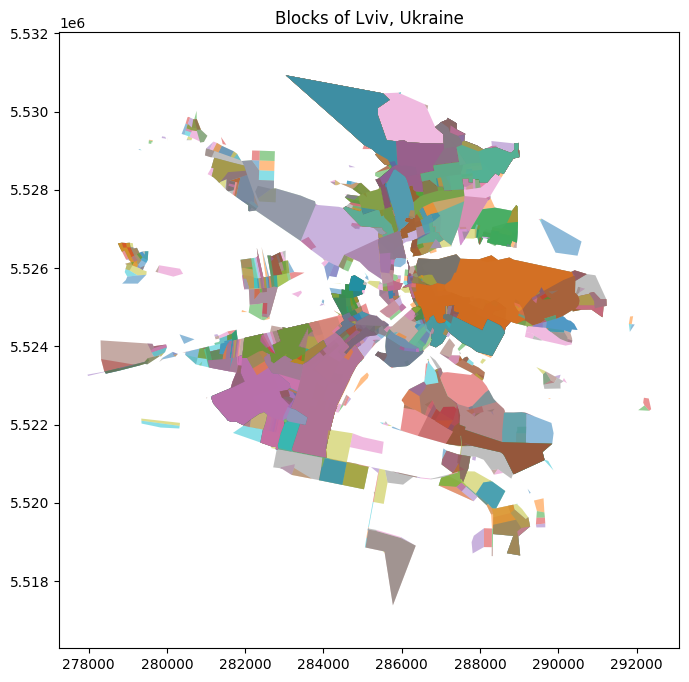

100%|██████████| 1228/1228 [00:00<00:00, 1278.40it/s]


In [218]:
a_city_name = "Lviv, Ukraine"
a_blocks = get_city_blocks(a_city_name)
a_block_data = compute_shape_factor(a_blocks)

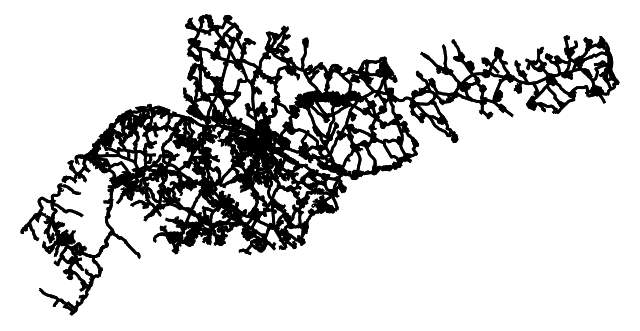

100%|██████████| 7655/7655 [14:20<00:00,  8.90it/s]  


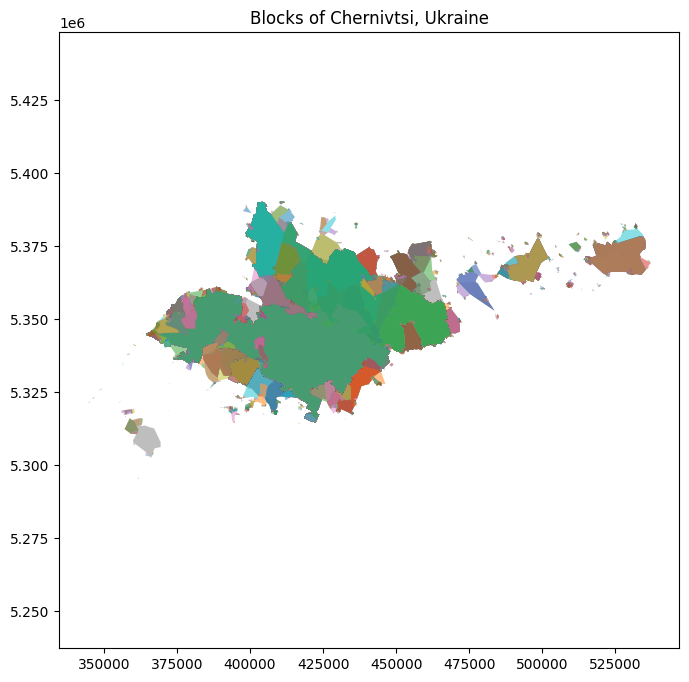

100%|██████████| 7597/7597 [00:06<00:00, 1218.22it/s]


In [221]:

b_city_name = "Chernivtsi, Ukraine"
b_blocks = get_city_blocks(b_city_name)
b_block_data = compute_shape_factor(b_blocks)

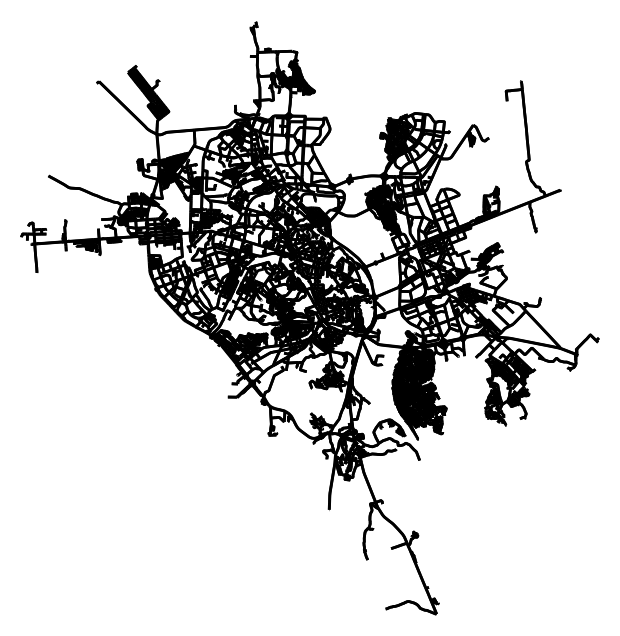

100%|██████████| 4026/4026 [00:24<00:00, 162.00it/s]


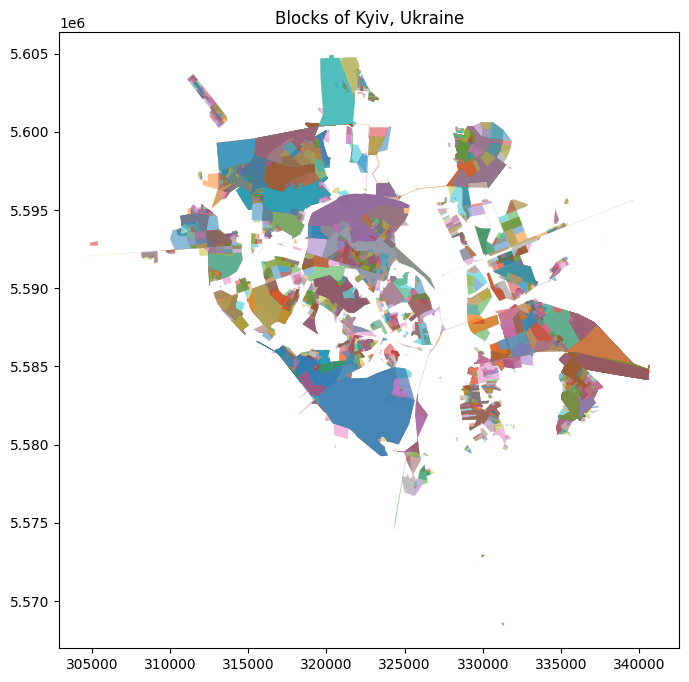

100%|██████████| 3626/3626 [00:02<00:00, 1283.60it/s]


In [225]:
c_city_name = "Kyiv, Ukraine"
c_blocks = get_city_blocks(c_city_name)
c_block_data = compute_shape_factor(c_blocks)

C:\Users\Max\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\osmnx\_overpass.py:267: UserWarning: This area is 13 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


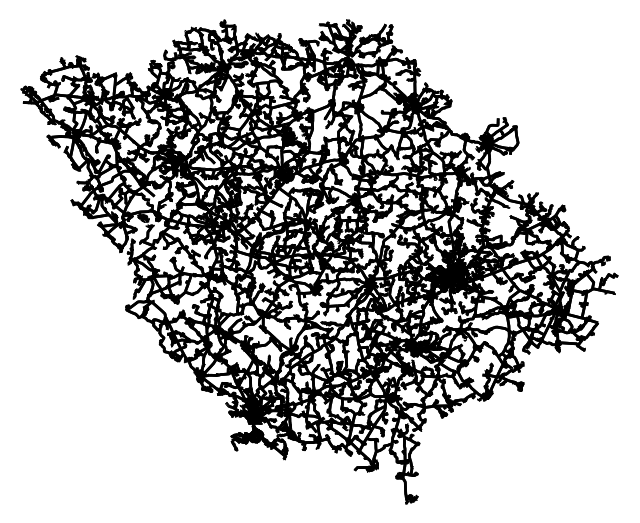

100%|██████████| 15176/15176 [02:56<00:00, 86.06it/s] 


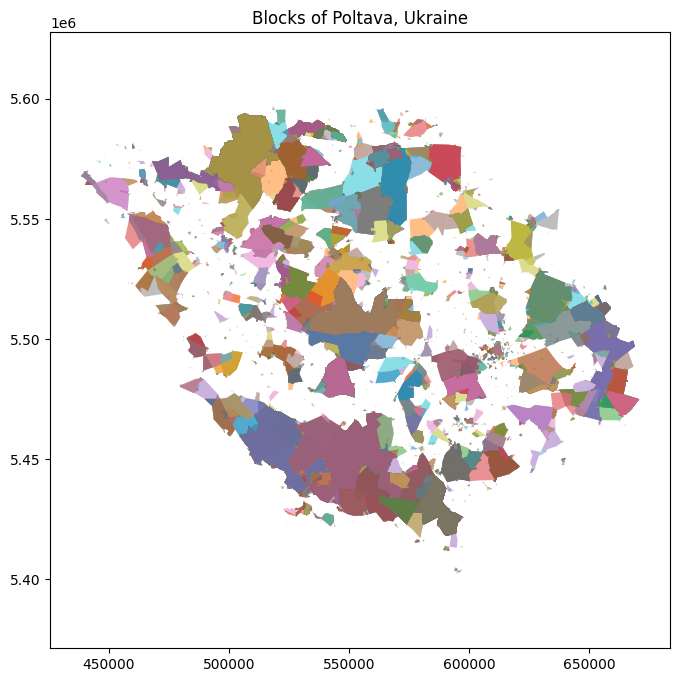

100%|██████████| 14571/14571 [00:13<00:00, 1084.84it/s]


In [227]:
d_city_name = "Poltava, Ukraine"
d_blocks = get_city_blocks(d_city_name)
d_block_data = compute_shape_factor(d_blocks)

C:\Users\Max\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\osmnx\_overpass.py:267: UserWarning: This area is 15 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


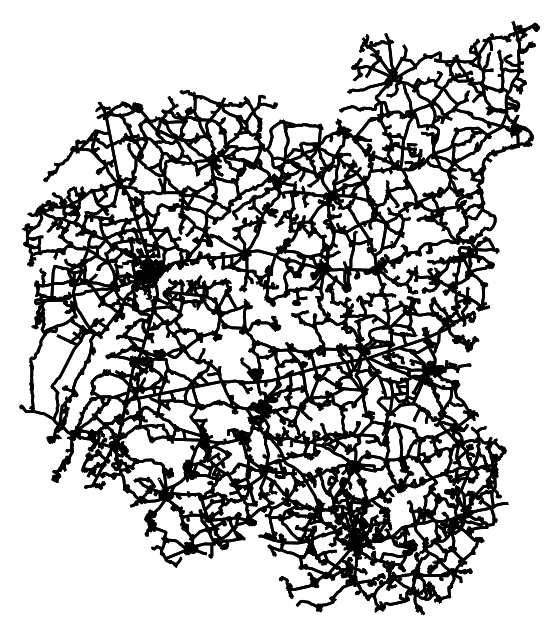

100%|██████████| 12258/12258 [10:05<00:00, 20.23it/s]  


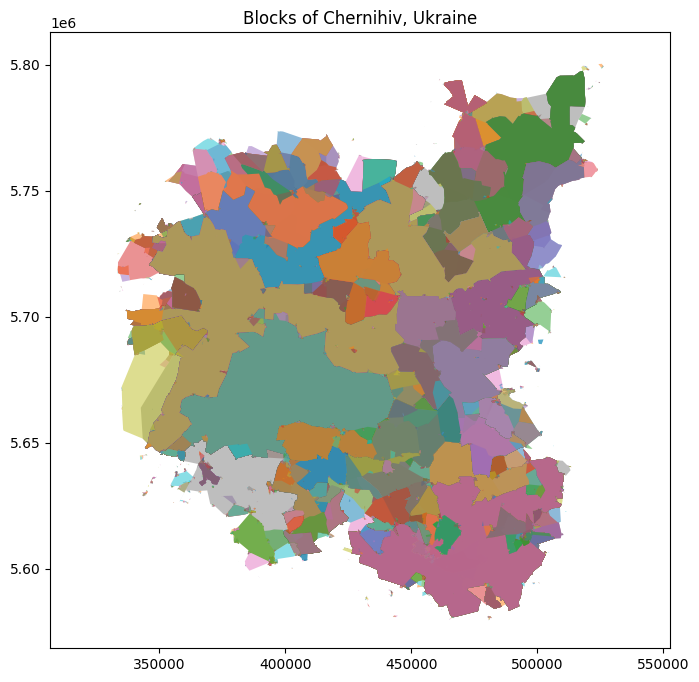

100%|██████████| 12150/12150 [00:12<00:00, 996.80it/s] 


In [228]:
e_city_name = "Chernihiv, Ukraine"
e_blocks = get_city_blocks(e_city_name)
e_block_data = compute_shape_factor(e_blocks)

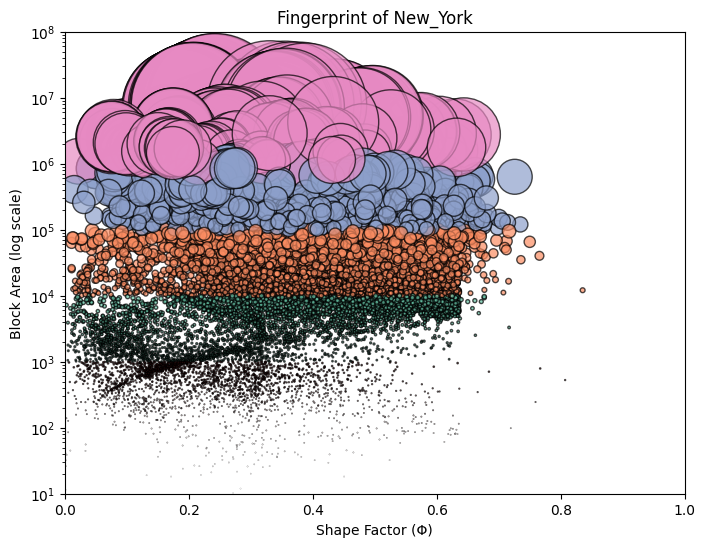

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


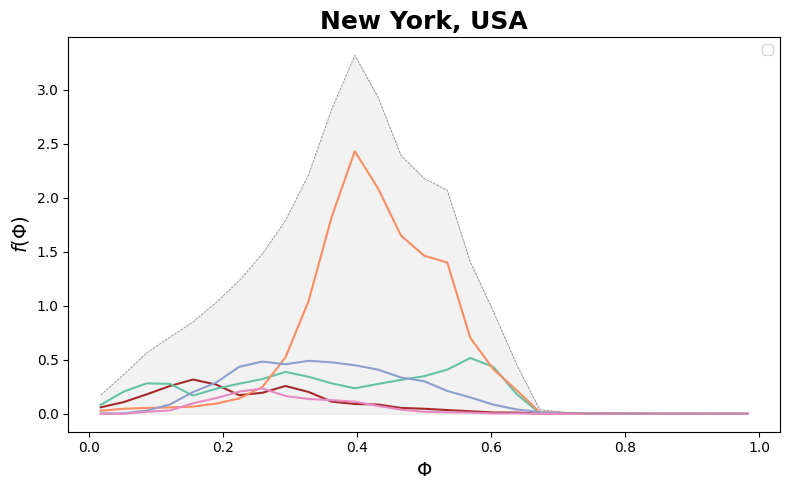

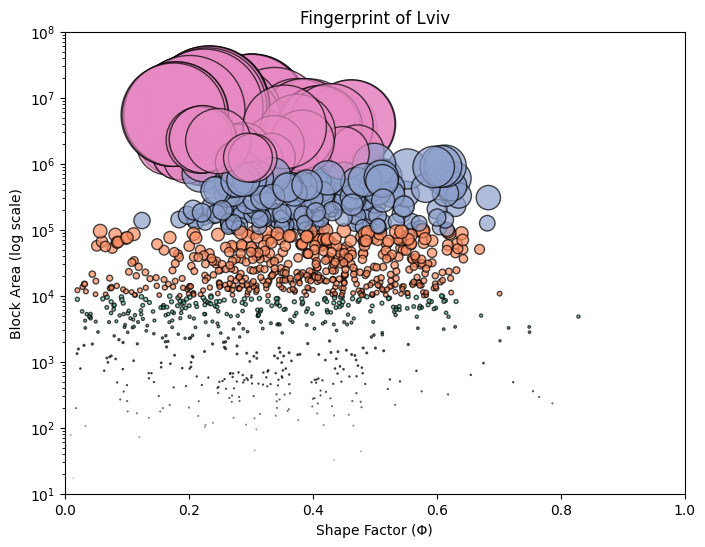

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


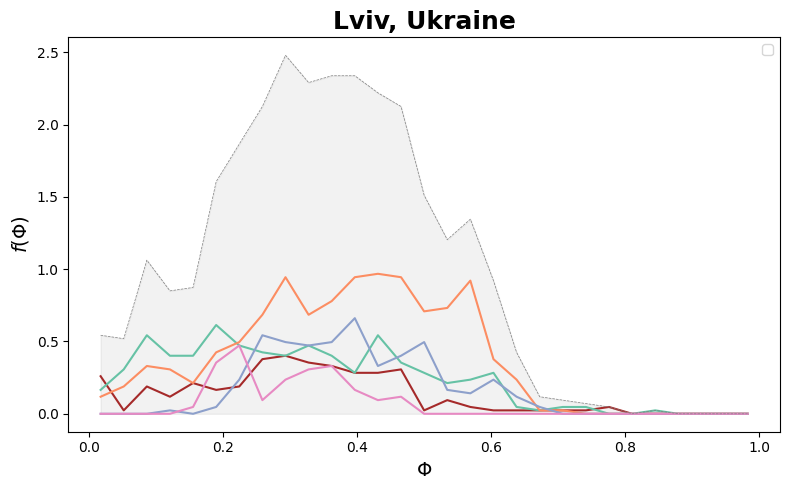

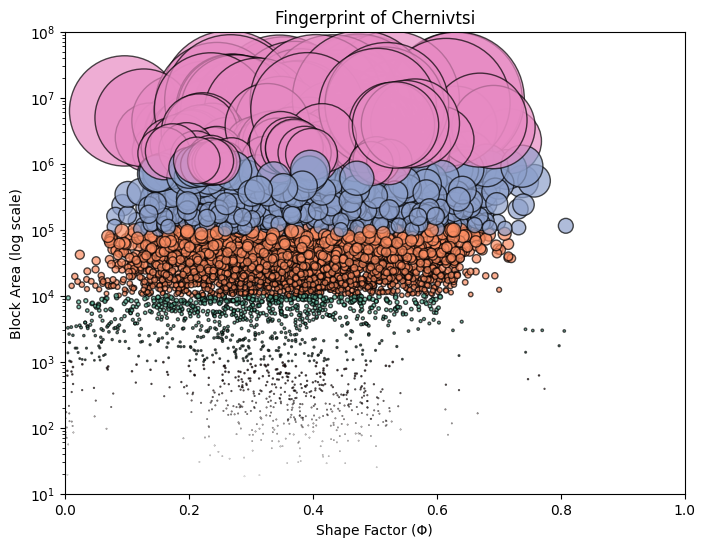

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


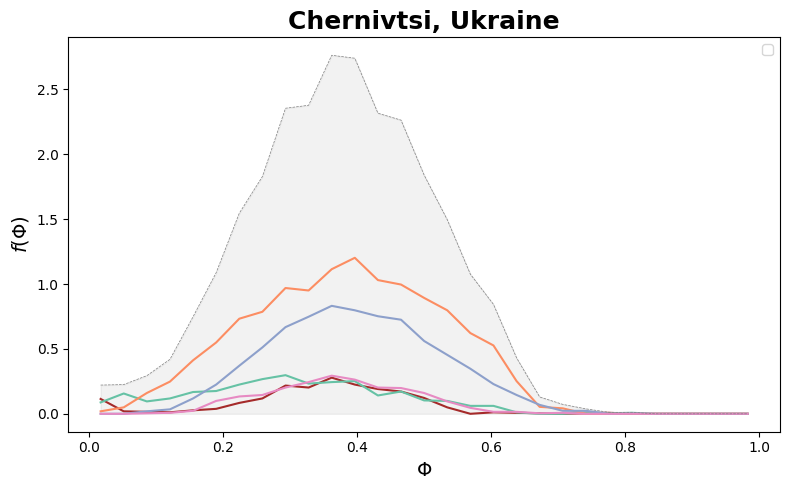

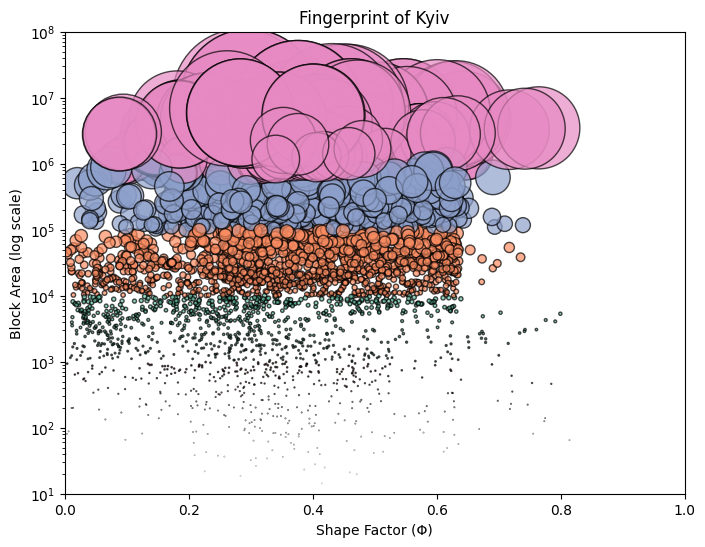

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


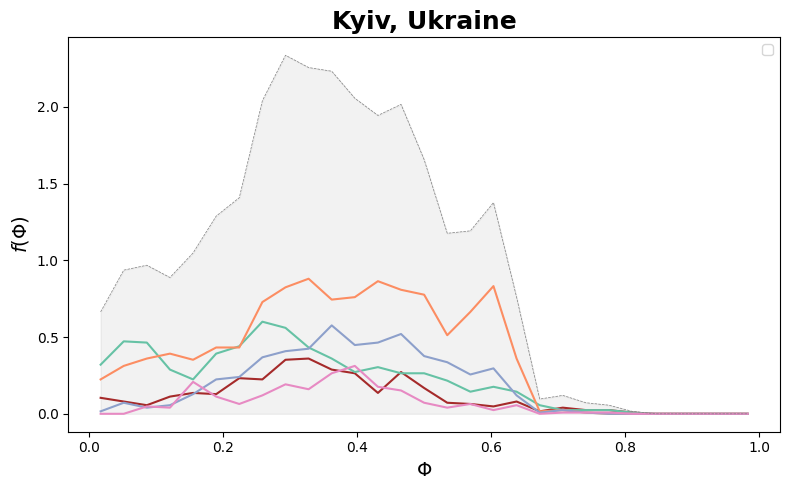

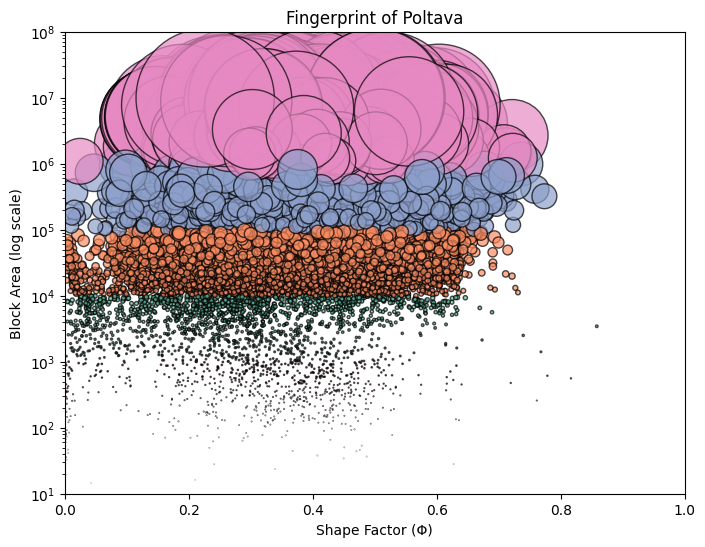

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


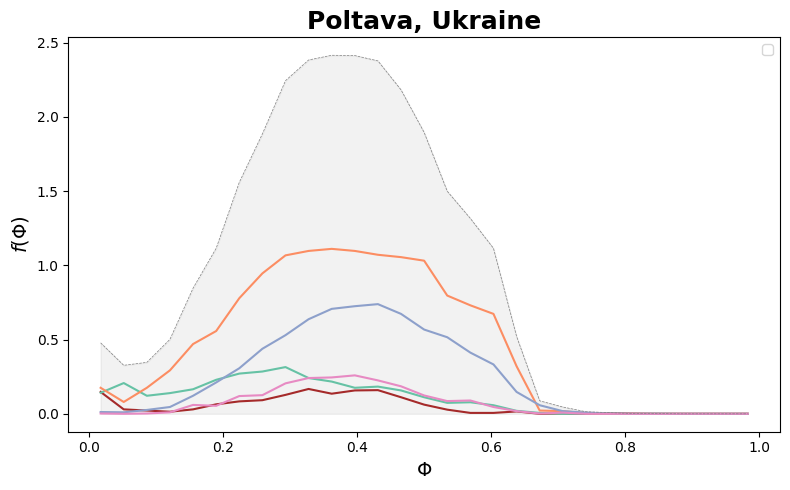

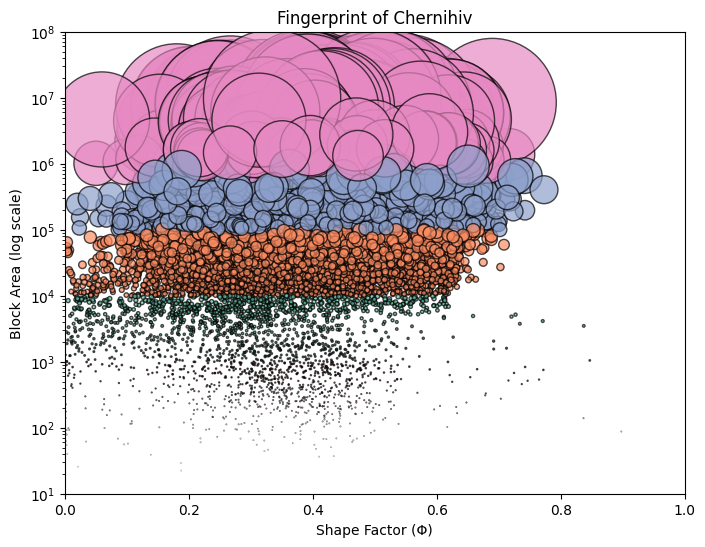

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


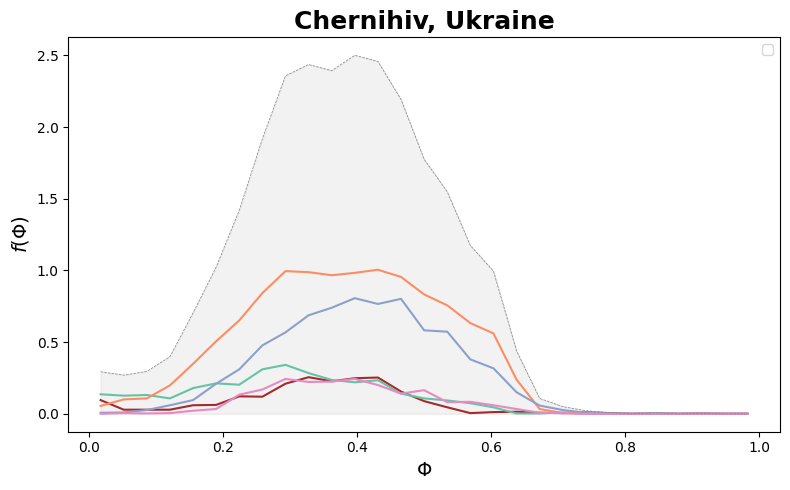

	New York, USA	Lviv, Ukraine	Chernivtsi, Ukraine	Kyiv, Ukraine	Poltava, Ukraine	Chernihiv, Ukraine
New York, USA	0.0000	0.5909	0.5763	0.7198	0.6356	0.6507	
Lviv, Ukraine	0.5909	0.0000	0.2518	0.1892	0.1949	0.2261	
Chernivtsi, Ukraine	0.5763	0.2518	0.0000	0.2013	0.0787	0.0612	
Kyiv, Ukraine	0.7198	0.1892	0.2013	0.0000	0.1225	0.2015	
Poltava, Ukraine	0.6356	0.1949	0.0787	0.1225	0.0000	0.0544	
Chernihiv, Ukraine	0.6507	0.2261	0.0612	0.2015	0.0544	0.0000	


In [255]:
cities = {
    city_name  : block_data,
    a_city_name: a_block_data,
    b_city_name: b_block_data,
    c_city_name: c_block_data,
    d_city_name: d_block_data,
    e_city_name: e_block_data,
}

distances = np.zeros((len(cities), len(cities)))
for i, (city_a, data_a) in enumerate(cities.items()):
    plot_fingerprint(data_a, city_a)
    plot_pd(data_a, city_a)
    for j, (city_b, data_b) in enumerate(cities.items()):
        distances[i, j] = distance_between_cities(data_a, data_b)
        # print(f"Distance between {city_a} and {city_b}: {distances[i, j]:.4f}")

# printing it as a table
print("\t" + "\t".join(cities.keys()))
for i, (city_a, data_a) in enumerate(cities.items()):
    print(city_a, end="\t")
    for j, (city_b, data_b) in enumerate(cities.items()):
        print(f"{distances[i, j]:.4f}", end="\t")
    print()